In [168]:
%load_ext autoreload
%autoreload 2


from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

import sys
sys.path.append('../src/')
sys.path.append('../tests/')
from tests import *
from time import time


from utils import *
from Instance import *
from Solution import *
from metaheuristic_approach import *


from copy import deepcopy
from time import time


##### MILP MODEL #####
import gurobipy as gp
from gurobipy import GRB

from first_model import *



# fonction de validation des chromosomes
from validator_metaheuristique import (
    validate_best_chromosomes,
    print_validation_summary,
)

#fonction de validation des solutions MILP
from validator_model import (
    solve_and_validate_model,
    validate_model_solutions,
    print_validation_summary,
    validate_model_solution,
)



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [169]:
TIME_DAY = 42 # 42 unités de temps = 1 journée de travail soit 7h

In [170]:
time_type_of_jobs = {
    "small": (3, 9),
    "medium": (9, 18),
    "long": (18, 42)
}

Seed aléatoire pour l'instance : 3305
set
[{0, 3, 5, 8, 14, 18, 25, 27, 30, 33, 35, 38, 45, 46, 47, 48, 51, 55, 58, 62, 63, 66, 70, 71, 72, 78, 84, 86, 91, 103, 105, 110, 113, 119, 120, 123, 124, 131, 137, 138, 141, 147, 150, 153, 156, 161, 162, 166, 170, 171, 172, 183, 188, 191, 193, 197, 198, 203, 204, 207, 208, 212, 219, 221, 225, 229, 230, 231, 234, 237, 239, 250, 254, 259, 261, 263, 267, 269, 273, 274, 278, 281, 282, 284, 285, 290, 292, 297, 298, 299, 300, 308, 309, 310, 311, 316, 321, 322, 326, 329, 336, 339, 341, 351, 354, 355, 358, 363, 364, 368, 369, 372, 373, 374, 377, 381, 383}, {1, 7, 9, 12, 13, 15, 20, 21, 22, 24, 26, 28, 29, 31, 32, 36, 37, 39, 41, 42, 43, 44, 49, 56, 57, 61, 68, 74, 77, 79, 80, 81, 83, 85, 89, 95, 96, 100, 101, 104, 107, 108, 111, 112, 114, 117, 118, 121, 122, 125, 126, 127, 128, 129, 133, 135, 136, 140, 142, 143, 144, 145, 149, 151, 158, 159, 164, 165, 167, 173, 176, 178, 179, 182, 185, 186, 189, 194, 195, 196, 202, 211, 213, 216, 220, 222, 224, 227, 22

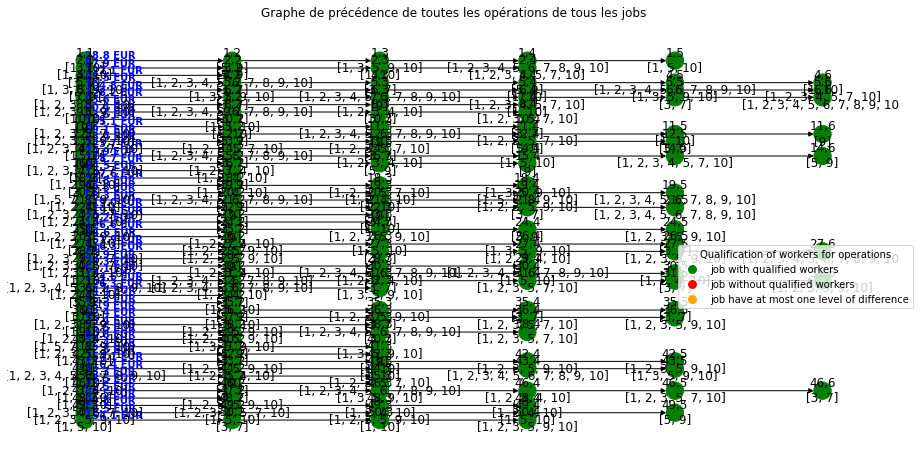

In [171]:
seed = np.random.randint(0, 10000)
print(f"Seed aléatoire pour l'instance : {seed}")
seed = 7185
config_instance = {
    "seed": seed,

    "nb_jobs": 50,
    "nb_workers": 10,
    "nb_professions": 5,
    "proportion_tasks_per_profession": [0.2, 0.2, 0.2, 0.2, 0.2], # [profession 1, profession 2, profession 3, profession 4, profession 5]
    "max_nb_operations": 7,
    "nb_tasks" : "lower", # "lower", "medium", "high"

    # "proportion_jobs": [0.3, 0.4, 0.3], # [small_jobs, medium_jobs, long_jobs]

    "proportion_tasks_without_collaborative_work": 0.2,
    "proportion_tasks_level_required": 0.1,

    "proportion_tasks_times" : [0.3, 0.4, 0.3], # [small_tasks (30 unités), medium_tasks (), long_tasks]
    "time_type_of_jobs" : time_type_of_jobs,
    "proportion_tasks_levels":[ 0.1, 0.1, 0.4, 0.4], # [level 1, level 2, level 3, level 4]

    "proportion_workers_levels":[ 0.3, 0.3, 0.1, 0.1], # [level 1, level 2, level 3, level 4]

    "at_least_a_worker_have_competence_for_each_profession": True
}

instance = Instance()
instance.from_config(config_instance)

visualization_before_scheduling(instance, not_qualified=True)

In [172]:
instance.visualize_jobs_overview()

In [235]:
instance.resale_price_jobs

array([ 28.77369975,  87.87560463, 122.13750667,  68.4538872 ,
       104.78816571, 128.21775223,  93.58510527,  90.35088198,
        93.62179971, 155.14288449,  69.07805285,  43.39087238,
       123.67838399,  24.93792643, 118.72969075,  84.50241241,
       147.60209884,  29.77055301,  99.78233941,  58.31998548,
       118.96307311, 119.58563828,  79.21774755, 126.56442886,
        44.56845731, 151.89224385, 116.33415141,  53.86960787,
        38.27335471,  65.09903201, 124.62359328, 126.30045378,
        94.36704614,  45.29516941,  75.92563021,  62.44452097,
        33.3539657 ,  75.50286468,  80.75459536,  22.3745631 ,
        22.84809054, 154.14265518, 116.37328573,  33.33508544,
        58.49728366,  62.51511715,  97.53630414,  99.79750071,
        54.48804818, 154.11410477])

In [173]:
constraints_config = {"job_with_no_skills": False,
                        "constrained_makespan": TIME_DAY,
                        "no_base_worker" : False,
                        "no_solo_tasks": False,
                 }

In [174]:
weights = {
    "profit" : 100,
    "skills" : 10,
    "cognitive_load" : 1
    }

# #1 Random Search

In [130]:
# c_list = []
# for i in range(ONE_NB_SEED):
#     print("iteration : ", i)
#     c_list.append(gen.generate_random())
#     print("chromosome : ", c_list[i])
#     voisins = PrioritizeUnfinishedJobNeighborhood(instance=instance).generate(c_list[i])
#     print("voisins : ", voisins)
#     for v in voisins:
#         print("voisin : ", v)
#     print("--------")

In [ ]:
ONE_NB_SEED = 30
MAX_EVAL = 5000

enc   = Encoding_Dicos(instance)
gen   = ChromosomeGenerator(instance, enc, constraints_config=constraints_config)
dec   = Decoder(instance, enc, constraints_config=constraints_config)
eval  = Evaluator(dec, weights)
sel   = BestSelector()


In [176]:
rs_times = np.zeros(ONE_NB_SEED)
rs_all_viewed = []
rs_best_list = []
rs_index_best_list = []

In [177]:
for nb_seed in range(ONE_NB_SEED):

    rs = RandomSearch(gen, eval)
    t = time.time()

    av, bl, indx_bests, best_c = rs.run(MAX_EVAL, verbose=False)
    
    rs_times[nb_seed] = time.time() - t
    rs_all_viewed.append(av)
    rs_best_list.append(bl)
    rs_index_best_list.append(indx_bests)

Random Search Iterations: 100%|██████████| 5000/5000 [01:02<00:00, 80.09it/s]


In [178]:
for i in range(ONE_NB_SEED):
    print(f"Seed {i+1}:")
    print(rs_best_list[i][-1].fitness)
    print(rs_best_list[i][-1].objectives)
    print(f"Time taken: {rs_times[i]:.2f} seconds\n")

Seed 1:
67210.39501126153
(673.7855347557369, 2.5, -193.15846431215965)
Time taken: 65.50 seconds

Seed 2:
66657.0129410485
(668.1339297132268, 4.0, -196.38003027419396)
Time taken: 67.10 seconds

Seed 3:
70212.70943373119
(704.0177460695797, 3.0, -219.06517322678837)
Time taken: 62.74 seconds

Seed 4:
70310.854037611
(704.9993946181355, 2.0, -209.08542420254872)
Time taken: 64.58 seconds

Seed 5:
71612.82987940309
(718.2343106517652, 2.946540865674649, -240.06659443018512)
Time taken: 62.43 seconds

Seed 6:
71033.23500781128
(712.153536113565, 2.0, -202.11860354522452)
Time taken: 61.12 seconds

Seed 7:
69052.83493087238
(692.1606794856543, 2.446540865674649, -187.69842634980154)
Time taken: 60.54 seconds

Seed 8:
67503.6897371409
(676.467945804413, 2.933327147452644, -172.43811477491911)
Time taken: 61.46 seconds

Seed 9:
66496.32504530126
(666.6472188520413, 2.5, -193.3968399028724)
Time taken: 60.74 seconds

Seed 10:
80733.52645756895
(809.3706754598154, 1.0, -213.5410884125854)
Ti

In [179]:
rs_index_best_list

[[0, 3, 9, 10, 12, 13, 47, 75, 111, 308, 359, 1487, 1977],
 [0, 2, 6, 12, 144, 200, 520],
 [0, 2, 9, 10, 11, 81, 105, 124, 242, 271, 1009],
 [0, 3, 9, 17, 105, 340, 1207, 1303, 2421],
 [0, 1, 4, 6, 23, 225, 608, 1509, 1621],
 [0, 1, 2, 3, 14, 25, 56, 74, 179, 828, 1068, 2173],
 [0, 1, 3, 6, 14, 49, 959, 1413],
 [0, 1, 2, 14, 19, 40, 44, 46, 93, 612, 804],
 [0, 2, 3, 6, 9, 186, 336, 423, 1042, 1797, 3699],
 [0, 2, 13, 30, 41, 62, 114, 829, 2130],
 [0, 1, 24, 104, 143, 181, 263, 473, 647, 2981, 3629, 4251],
 [0, 11, 15, 25, 140, 287, 380, 856, 1523],
 [0, 1, 3, 8, 29, 44, 86, 334, 379, 696, 706, 886, 2559],
 [0, 2, 4, 116, 130, 276, 490, 760, 4298],
 [0, 1, 2, 571, 4142, 4467],
 [0, 19, 22, 45, 75, 238, 825, 2669, 3135, 4480],
 [0, 1, 2, 22, 66, 79, 87, 114, 271, 571, 631, 854, 1790, 2059],
 [0, 4, 8, 40, 1577, 2714],
 [0, 2, 3, 7, 16, 59, 67, 83, 128, 130, 142, 290, 859, 1701, 2853, 3036],
 [0, 1, 4, 5, 8, 38, 49, 50, 54, 360, 396, 779],
 [0, 1, 7, 10, 14, 19, 35, 250, 323, 491, 600, 84

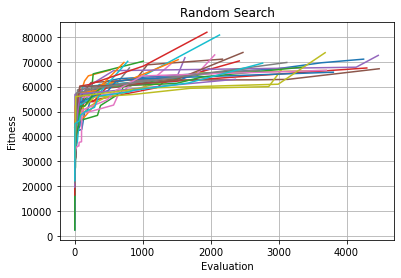

In [272]:
rs_best_list_fitness = [ [c.fitness for c in rs_best_list[i]] for i in range(ONE_NB_SEED) ]


for i in range(ONE_NB_SEED):
    plt.plot(rs_index_best_list[i], rs_best_list_fitness[i])
    plt.xlabel("Evaluation")
    plt.ylabel("Fitness")
    plt.title(f"Random Search")
plt.grid()
plt.show()

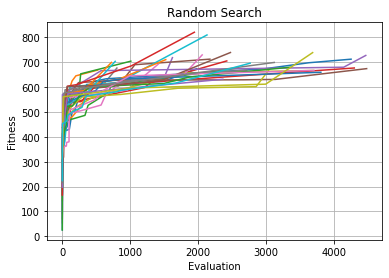

In [ ]:
rs_best_list_objectif_economic = [ [c.objectives[0] for c in rs_best_list[i]] for i in range(ONE_NB_SEED) ]
for i in range(ONE_NB_SEED):
    plt.plot(rs_index_best_list[i], rs_best_list_objectif_economic[i]) 
    plt.xlabel("Evaluation")
    plt.ylabel("Fitness")
    plt.title(f"Random Search")
plt.grid()
plt.show()

In [188]:
res_rs = []
for i in range(ONE_NB_SEED):
    res_rs.append(rs_best_list[i][-1].objectives[0])
mean_rs = np.mean(res_rs)
max_rs = np.max(res_rs)
min_rs = np.min(res_rs)
median_rs = np.median(res_rs)
print(f"Mean of the best economic objective over {ONE_NB_SEED} seeds: {mean_rs:.2f}") 
print(f"Max of the best economic objective over {ONE_NB_SEED} seeds: {max_rs:.2f}")
print(f"Min of the best economic objective over {ONE_NB_SEED} seeds: {min_rs:.2f}")
print(f"Median of the best economic objective over {ONE_NB_SEED} seeds: {median_rs:.2f}")

Mean of the best economic objective over 30 seeds: 699.90
Max of the best economic objective over 30 seeds: 820.24
Min of the best economic objective over 30 seeds: 631.40
Median of the best economic objective over 30 seeds: 697.33


# #2 RS + VNS

In [293]:
rs_vns_times = np.zeros(ONE_NB_SEED)
rs_vns_all_viewed = []
rs_vns_best_list = []
rs_vns_index_best_list = []
rs_vns_best_c = []

In [294]:
ONE_NB_SEED = 10
MAX_EVAL = 2000

In [295]:
for nb_seed in range(ONE_NB_SEED):
    print(f"\n\nSeed {nb_seed+1}:")

    t = time.time()

    rs = RandomSearch(gen, eval)
    rs_av, rs_bl, rs_indx_bests, rs_best_c = rs.run(MAX_EVAL//2, verbose=False)
    print(f"Random Search for seed {nb_seed+1}: {rs_best_c.fitness} : {rs_best_c.objectives}")
    
    vns = VNS(gen, eval, ls_neighborhood, neighborhoods, sel, ls_patience=100)
    vns_av, vns_bl, vns_indx_bests, vns_best_c = vns.run(MAX_EVAL//2, init_chromosome=best_rs_init, verbose=False)
    
    rs_vns_times[nb_seed] = time.time() - t

    rs_vns_all_viewed.append(rs_av+vns_av)
    rs_vns_best_list.append(rs_bl+vns_bl)
    rs_vns_index_best_list.append(rs_indx_bests+vns_indx_bests)
    rs_vns_best_c.append(vns_best_c)


Random Search Iterations:   0%|          | 0/1000 [00:00<?, ?it/s]



Seed 1:


Random Search Iterations: 100%|██████████| 1000/1000 [00:34<00:00, 29.32it/s]


Random Search for seed 1: 64654.92900380026 : (647.8994161056349, 4.0, -175.0126067632355)

Nombre d'appels par voisinage :
[5, 2, 1, 1, 1]
best = 102615.63403007523 objectives= (1028.5697816126597, 3.0, -271.34413119073713) evals= 1000


Random Search Iterations:   1%|          | 6/1000 [00:00<00:17, 57.51it/s]

...

Random Search for seed 9: 59184.50598526698 : (593.6249886784583, 3.0, -207.9928825788488)


Random Search Iterations:   0%|          | 5/1000 [00:00<00:23, 43.23it/s]


Nombre d'appels par voisinage :
[4, 2, 2, 1, 1]
best = 97746.02027519907 objectives= (979.6418887797283, 4.0, -258.16860277376406) evals= 1000


Seed 10:


Random Search Iterations: 100%|██████████| 1000/1000 [00:13<00:00, 73.83it/s]


Random Search for seed 10: 73831.0920542235 : (739.6911684583042, 4.0, -178.02479160692388)

Nombre d'appels par voisinage :
[4, 2, 2, 1, 1]
best = 93972.7746533394 objectives= (941.786922695242, 5.0, -255.91761618479373) evals= 1000


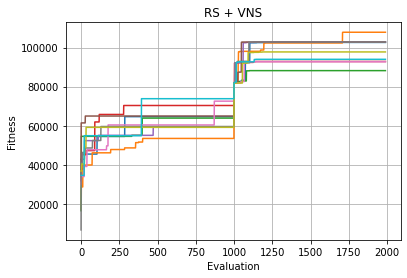

In [296]:
rs_vns_all_viewed_objectif = [ [c.fitness for c in rs_vns_all_viewed[i]] for i in range(ONE_NB_SEED) ]

for i in range(ONE_NB_SEED):
    y = np.array(rs_vns_all_viewed_objectif[i])
    y = np.maximum.accumulate(y)
    plt.plot(y)
    plt.xlabel("Evaluation")
    plt.ylabel("Fitness")
    plt.title(f"RS + VNS")
plt.grid()
plt.show()

In [299]:
# Recuperer meilleure solution de rs+vns 

rs_vns_best_fitness_per_seed = np.zeros(ONE_NB_SEED)
for i in range(ONE_NB_SEED):
    rs_vns_best_fitness_per_seed[i] = rs_vns_best_c[i].fitness

In [302]:
indx_best = np.argmax(rs_vns_best_fitness_per_seed)
best_chromosome_find = rs_vns_best_c[indx_best]
best_solution_find = dec.decode_solution(best_chromosome_find)

In [306]:
row, ok = validate_model_solution(
    instance=instance,
    solution=best_solution_find,
    constraints_config=constraints_config,
    )
display(pd.DataFrame([row]))

Exécution du test solution_valide...
nb_job_no_skills=0
Exécution du test base_worker...
Exécution du test need_level_if_solo...


,Nom,C_max,Profit,Profit_job_done,Skill_gain,Cognitive_load,solution_valide,base_worker,need_level_if_solo,OK
0,solution,42,1080.439389,1035.439389,4.0,266.373292,PASS,PASS,PASS,TRUE


# #4 Init solution dans MILP

In [ ]:
model = Model(instance)

constraints_config["init_affectation_variables"] = [
    best_solution_find.x,
    best_solution_find.d,
    best_solution_find.task_done,
    best_solution_find.z_auxilary
]

In [ ]:
model.solve(
    objective="lexicographic", 
    weight=weights, 
    priority=[2, 1, 0], 
    constraints_config=constraints_config, 
    verbose=True
)


 ========== SOLVING MODEL ========== 
EPS= 0.0001
job with no skills desactived
nb_job_with_no_skills =  0
limite MAKESPAN =  42
constrained makespan activated with limit = 42
constrained makespan activated with self.BORNE_SUP_MAKESPAN = 42
init affectation variables activated
$*$*$*$*$*$ initial affectation variables set to x_initial $*$*$*$*$*$
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
No optimal solution found. Status code: 11


# #3 VNS

In [245]:
def build_neighborhoods(gen, nb_job_no_skills=0):
    """Retourne la liste des voisinages à tester — modifier ici pour ajouter/retirer un voisinage."""
    return [
        # (MoveOneOperationNeighborhood(),                                      "Move OSC"),
        # (MoveSecondWorkerNeighborhood(gen),                                   "Move SWAC"),
        (MoveJobNeighborhood(n=25), "Move Job"),  # k=1 perturbation moyenne
        (ShuffleOperationsNeighborhood(n=25, nb_job_no_skills=nb_job_no_skills), "Shuffle OSC"),
        (SwapOperationNeighborhood(n=25, nb_job_no_skills=nb_job_no_skills), "Swap OSC"),
        (ChangebaseWorkerNeighborhood(nb_job_no_skills=nb_job_no_skills, generator=gen), "Change Base Worker"),
        (RandomRestartNeighborhood(gen, n=1, nb_job_no_skills=nb_job_no_skills), "Random Restart"),
    ]

neighborhoods = build_neighborhoods(gen, nb_job_no_skills=0)
ls_neighborhood = (SwapOperationNeighborhood(n=1, nb_job_no_skills=0), "Swap OSC")
ls_neighborhood = (PrioritizeUnfinishedJobNeighborhood(instance, n=1, nb_job_no_skills=0), "Prioritize Unfinished Job")

In [254]:
best_ch_rs = np.zeros(len(rs_best_list_objectif_economic))
for i in range(len(rs_best_list_objectif_economic)):
    best_ch_rs[i] = rs_best_list_objectif_economic[i][-1]

In [256]:
np.argmax(best_ch_rs)

23

In [257]:
best_rs_init = rs_best_list[np.argmax(best_ch_rs)][-1]

In [259]:
print(best_rs_init)

osc :
[25 25 25 25 25 16 16 42 42 42 42 42  1  1  1  1 21 21 21  2  2  0  0  0
  0  0  9  9  9  9 48 48 48 48 48  7  7  7  7 19 19 19 19 11 11 11 11 11
 23 23 23 23 23  3  3  3  3  3  3  8  8 26 26 26 26 26 26 12 12 12 20 20
 20 20 20 30 30 30 30 30 30 15 15 45 45 45 45 45 45 41 41 41 41 41 28 28
 28 28 22 22 22 34 34 34 34 34 18 18 18 18 18 33 33 13 13 13 13 13 13 35
 35 35 35 35 32 32 17 17 17 17  4  4  4  4  4  4  6  6  6  6 43 43 43  5
  5  5  5  5  5 39 39 39 10 10 10 10 10 10 31 31 31 40 40 40 38 38 27 27
 47 47 47 47 37 37 37 37 46 46 49 49 49 49 14 14 14 14 44 44 44 24 24 29
 29 29 29 29 36 36 36]
fwac:
[ 9  4  4  4  4  9  4  9  9  6  6  8  2 -1 -1 -1 -1  4 -1 -1 -1 -1 -1  6
 -1 -1 -1 -1 -1  8  8 -1 -1  9 -1 -1 -1  8 -1  0  0  0  6  8  8  8  4 -1
 -1  4  1  1 -1 -1  9  9  2  8  2 -1 -1 -1 -1  6 -1 -1 -1  4  9  9  8  6
 -1 -1 -1  8  4  1 -1 -1  1 -1 -1 -1  6 -1 -1 -1 -1  3  2  2  8  2 -1  2
 -1 -1 -1 -1 -1 -1  2  2  4  2  2  6 -1 -1 -1 -1 -1  4  8  1  1  4  1  0
  0  0  0  0  7 

In [262]:
vns_times = np.zeros(ONE_NB_SEED)
vns_all_viewed = []
vns_best_list = []
vns_index_best_list = []
vns_best_c = []

for nb_seed in range(ONE_NB_SEED):
    print(f"VNS - Seed {nb_seed+1}/{ONE_NB_SEED}")

    vns = VNS(gen, eval, ls_neighborhood, neighborhoods, sel, ls_patience=100)
    t = time.time()

    av, bl, indx_bests, best_c = vns.run(MAX_EVAL, init_chromosome=best_rs_init, verbose=False)
    
    vns_times[nb_seed] = time.time() - t
    vns_all_viewed.append(av)
    vns_best_list.append(bl)
    vns_index_best_list.append(indx_bests)
    vns_best_c.append(best_c)


VNS - Seed 1/30

Nombre d'appels par voisinage :
[12, 10, 10, 9, 9]
best = 86699.26447966859 objectives= (868.9781465773067, 4.0, -238.55017806207488) evals= 5000
osc :
[38 23 19 25 37 23  6 46  9  8 20 45 19 47 27  7 14  2 20  9 46 14 14 37
 27 45 30 36 40 36 45  6 30 30 30 36 25 14 19 45 37 23 20 20 20 30 25 47
 37 30  6 24 47  4  6 23 24 41 23 25 41  9 32  9  7 38 19  7 32 47  4 40
  7 41 45 45 40  8 25 41  4  2  4 41 16  4 44 16 42 42 39 42 42  4 42  1
  1  1  1 21  0 21 44 21  5 48  0 48 48 48 48  0  0  0 11 11 11 11 39 11
  3  3  3  3  3  3 26 26 26 26 26 26 12 12 12 15 15 28 28 28 28 22 22 22
 34 34 34 34 34 18 18 18 18 18 33 33 13 13 13 13 13 13 35 35 35 35 35 17
 17 17 17 43 43 43 44  5  5  5  5  5 10 10 10 10 39 10 10 31 31 31 49 49
 49 49 29 29 29 29 29]
fwac:
[ 9  4  4  4  4  9  4  9  9  6  6  8  2 -1 -1 -1 -1  4 -1 -1 -1 -1 -1  6
 -1 -1 -1 -1 -1  8  8 -1 -1  9 -1 -1 -1  8 -1  0  0  0  6  8  8  8  4 -1
 -1  4  1  1 -1 -1  9  9  2  8  2 -1 -1 -1 -1  6 -1 -1 -1  4  9  9  8  6

In [263]:
for i in range(ONE_NB_SEED):
    row, ok = validate_model_solution(
        instance=instance,
        solution=dec.decode_solution(vns_best_c[i]),
        constraints_config=constraints_config,
        )
    display(pd.DataFrame([row]))
    print("-----")

Exécution du test solution_valide...
nb_job_no_skills=0
Exécution du test base_worker...
Exécution du test need_level_if_solo...


,Nom,C_max,Profit,Profit_job_done,Skill_gain,Cognitive_load,solution_valide,base_worker,need_level_if_solo,OK
0,solution,42,868.978147,827.978147,4.0,238.550178,PASS,PASS,PASS,TRUE


-----
Exécution du test solution_valide...
nb_job_no_skills=0
Exécution du test base_worker...
Exécution du test need_level_if_solo...


,Nom,C_max,Profit,Profit_job_done,Skill_gain,Cognitive_load,solution_valide,base_worker,need_level_if_solo,OK
0,solution,42,1030.569782,981.569782,4.5,288.70628,PASS,PASS,PASS,TRUE


-----
Exécution du test solution_valide...
nb_job_no_skills=0
Exécution du test base_worker...
Exécution du test need_level_if_solo...


...

-----
Exécution du test solution_valide...
nb_job_no_skills=0
Exécution du test base_worker...
Exécution du test need_level_if_solo...


,Nom,C_max,Profit,Profit_job_done,Skill_gain,Cognitive_load,solution_valide,base_worker,need_level_if_solo,OK
0,solution,42,1082.439389,1035.439389,5.0,276.321206,PASS,PASS,PASS,TRUE


-----
Exécution du test solution_valide...
nb_job_no_skills=0
Exécution du test base_worker...
Exécution du test need_level_if_solo...


,Nom,C_max,Profit,Profit_job_done,Skill_gain,Cognitive_load,solution_valide,base_worker,need_level_if_solo,OK
0,solution,42,895.766284,847.766284,3.5,277.085183,PASS,PASS,PASS,TRUE


-----


In [264]:
for i in range(ONE_NB_SEED):
    print(f"Seed {i+1}:")
    print(vns_best_c[i].fitness)
    print(vns_best_c[i].objectives)
    # print(vns_best_c[i])
    print(f"Time taken: {vns_times[i]:.2f} seconds")
    print("-----")

Seed 1:
86699.26447966859
(868.9781465773067, 4.0, -238.55017806207488)
Time taken: 53.17 seconds
-----
Seed 2:
102813.27188131672
(1030.5697816126597, 4.5, -288.7062799492552)
Time taken: 29.86 seconds
-----
Seed 3:
98540.52790295624
(987.9030853441202, 4.5, -294.78063145578324)
Time taken: 28.41 seconds
-----
Seed 4:
92455.66082942895
(926.7722809061202, 4.0, -261.56726118306983)
Time taken: 38.51 seconds
-----
Seed 5:
107916.31445730451
(1081.4393894862678, 4.5, -272.62449132225964)
Time taken: 30.81 seconds
-----
Seed 6:
102725.24651368543
(1029.5697816126597, 5.0, -281.73164758053906)
Time taken: 28.18 seconds
-----
Seed 7:
110790.2718013967
(1110.3243769755438, 3.5, -277.1658961576903)
Time taken: 28.49 seconds
-----
Seed 8:
108099.01961498056
(1083.4393894862678, 3.5, -279.9193336462262)
Time taken: 29.18 seconds
-----
Seed 9:
108102.13146394702
(1083.4393894862678, 4.0, -281.80748467975496)
Time taken: 27.70 seconds
-----
Seed 10:
108013.47879702433
(1082.4393894862678, 4.5, -2

In [73]:
# print(c_list[0])
# print(dec.decode_solution(c_list[0]).x)

In [74]:
# c_list = [gen.generate_random() for _ in range(5)]
# f_neigh = ChangebaseWorkerNeighborhood(nb_job_no_skills=0, generator=gen)

# for i in range(len(c_list)):
#     row, ok = validate_model_solution(
#         instance=instance,
#         solution=dec.decode_solution(c_list[i]),
#         constraints_config=constraints_config,
#         )
#     display(pd.DataFrame([row]))

In [75]:
# for i in range(5):
#     ex_c = c_list[i]
#     print(ex_c.base_worker_assignment)
#     print("\nvoisinage base worker:")
#     voisins = f_neigh.generate(ex_c)
#     for j in range(len(voisins)):
#         print("voisin ", j, " :")
#         print(voisins[j].base_worker_assignment)
#         row, ok = validate_model_solution(
#         instance=instance,
#         solution=dec.decode_solution(voisins[j]),
#         constraints_config=constraints_config,
#         )
#         display(pd.DataFrame([row]))



#     print("-----------------")
#     print("-----------------")
#     print("-----------------")


In [78]:
# for i in range(ONE_NB_SEED):
#     print(f"Seed {i+1}:")
#     print(vns_best_list[i][0].fitness)
#     print(vns_best_list[i][0].objectives)
#     print(vns_best_list[i][0])

#     print("-----")

In [79]:
# print(s_milp.which_jobs_are_completed())
for i in range(ONE_NB_SEED):
    s_vns = dec.decode_solution(vns_best_c[i])
    print(s_vns.which_jobs_are_completed())
    print(vns_best_c[i])


 ========== Checking which jobs are completed: ==========
[2]
osc :
[4 1 4 4 2 7 6 1 0 7 3 8 8 5 3 1 5 4 8 7 2 6 2 7 3 5 6 3 8 7 0 7 5 1 9 8 1
 6 9 3 8 1 9 0]
fwac:
[ 0 -1 -1  2  2 -1 -1 -1 -1  2  3  2  2  2  3  0  0  2  0  0  0  0  2  0
  0  2  0  2  1  0 -1 -1 -1 -1 -1  0  1  1  1  1  1  2  2  2]
swac:
[-1 -1 -1  3  0 -1 -1 -1 -1 -1  2 -1  3  3 -1  3  3  0  1  3  1 -1  0 -1
  1  1  1  1  0  3 -1 -1 -1 -1 -1  1  0 -1  0  4 -1 -1 -1 -1]
fitness: 13459.46961924225
objectives: (135.1800581990447, 1.6283531464323602, -74.81973212654307)
base_worker_assignment:
[[0 2 2 3 0 0 1 3 1 2]
 [0 0 0 0 0 0 0 0 0 0]]

 ========== Checking which jobs are completed: ==========
[2]
osc :
[2 8 7 7 3 6 1 2 3 6 3 7 5 1 5 0 3 8 8 7 8 5 4 4 2 0 1 9 5 7 1 3 1 8 4 8 6
 0 4 6 9 9 1 7]
fwac:
[ 2  2  2  0  0 -1 -1 -1 -1  2  1  2  2  1  3  2  0  2  0  1  0  0  2  0
  0  0  0  2  1  0 -1 -1 -1 -1 -1  2  2  1  2  2  3  2  2  2]
swac:
[ 3 -1  1  4  2 -1 -1 -1 -1 -1  2 -1  3  3 -1  3  3  1  1  3  1 -1  0 -1
 -1  3  3

In [121]:
vns_best_list_objectif = [ [c.fitness for c in vns_best_list[i]] for i in range(2) ]
a = np.array(vns_best_list_objectif[0])
b = np.array(vns_best_list_objectif[1])

In [122]:
len(a), len(b)

(42, 46)

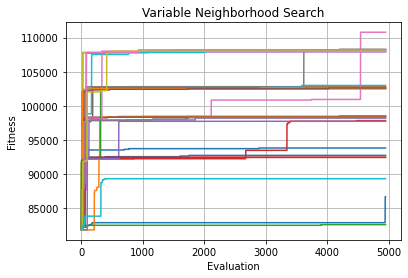

In [ ]:
vns_all_viewed_objectif = [ [c.fitness for c in vns_all_viewed[i]] for i in range(ONE_NB_SEED) ]

for i in range(ONE_NB_SEED):
    y = np.array(vns_all_viewed_objectif[i])
    y = np.maximum.accumulate(y)
    plt.plot(y)
    plt.xlabel("Evaluation")
    plt.ylabel("Fitness")
    plt.title(f"Variable Neighborhood Search")
plt.grid()
plt.show()

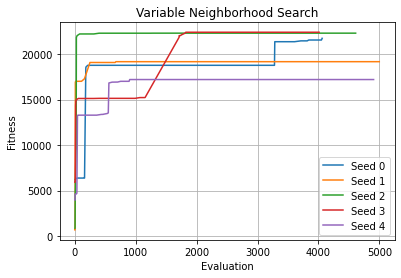

In [164]:
vns_best_list_objectif = [ [c.fitness for c in vns_best_list[i]] for i in range(ONE_NB_SEED) ]

for i in range(ONE_NB_SEED):
    y = np.array(vns_best_list_objectif[i])
    y = np.maximum.accumulate(y)
    plt.plot(vns_index_best_list[i], y, label=f"Seed {i}")
    plt.grid()
    plt.xlabel("Evaluation")
    plt.ylabel("Fitness")
    plt.title(f"Variable Neighborhood Search")
    plt.legend()
plt.show()

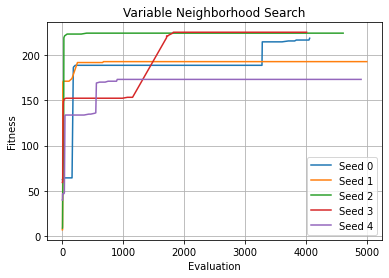

In [165]:
vns_best_list_objectif_economic = [ [c.objectives[0] for c in vns_best_list[i]] for i in range(ONE_NB_SEED) ]

for i in range(ONE_NB_SEED):
    y = np.array(vns_best_list_objectif_economic[i])
    y = np.maximum.accumulate(y)
    plt.plot(vns_index_best_list[i], y, label=f"Seed {i}")
    plt.grid()
    plt.xlabel("Evaluation")
    plt.ylabel("Fitness")
    plt.title(f"Variable Neighborhood Search")
    plt.legend()
plt.show()

# #3 MLS

In [103]:
neighborhoods_mls_1 = multipleNeighborhood_alternating(
    ChangebaseWorkerNeighborhood(nb_job_no_skills=0, generator=gen),
    PrioritizeUnfinishedJobNeighborhood(instance, nb_job_no_skills=0),
    nb_job_no_skills=0
)

neighborhoods_mls_2 = multipleNeighborhood_alternating(
    MoveOneOperationNeighborhood(),
    MoveSecondWorkerNeighborhood(gen),
    nb_job_no_skills=0
)

In [158]:
mls_times = np.zeros(ONE_NB_SEED)
mls_all_viewed = []
mls_best_list = []
mls_index_best_list = []

gen = ChromosomeGenerator(instance, enc, constraints_config=constraints_config)
curr_neigh = ChangebaseWorkerNeighborhood(nb_job_no_skills=0, generator=gen)


for nb_seed in range(ONE_NB_SEED):
    print(f"MLS - Seed {nb_seed+1}/{ONE_NB_SEED}")

    mls = MultipleLocalSearch(gen, eval, curr_neigh, sel)
    t = time.time()

    av, bl, indx_bests, best_c = mls.run(MAX_EVAL, patience=100,verbose=False)
    
    mls_times[nb_seed] = time.time() - t
    mls_all_viewed.append(av)
    mls_best_list.append(bl)
    mls_index_best_list.append(indx_bests)
    print("best fitness:", best_c.fitness, "best objectives:", best_c.objectives)

MLS - Seed 1/5
best fitness: 22400.347691365816 best objectives: (225.05291021020884, 0.5, -109.94332965506607)
MLS - Seed 2/5
best fitness: 24746.06903945527 best objectives: (248.6570190862041, 0.5, -124.63286916513947)
MLS - Seed 3/5
best fitness: 22411.186431894697 best objectives: (225.05291021020884, 1.5, -109.10458912618698)
MLS - Seed 4/5
best fitness: 24292.18443796873 best objectives: (243.6570190862041, 1.1283531464323602, -84.80100211599924)
MLS - Seed 5/5
best fitness: 24283.8666605046 best objectives: (243.6570190862041, 0.5, -86.83524811581015)


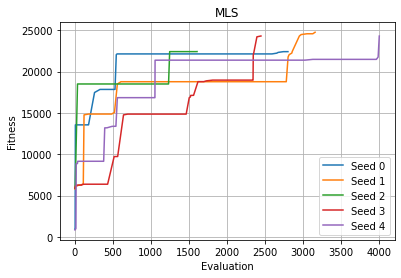

In [166]:
mls_best_list_objectif = [ [c.fitness for c in mls_best_list[i]] for i in range(ONE_NB_SEED) ]

for i in range(ONE_NB_SEED):
    y = np.array(mls_best_list_objectif[i])
    y = np.maximum.accumulate(y)
    plt.plot(mls_index_best_list[i], y, label=f"Seed {i}")
    plt.grid()
    plt.xlabel("Evaluation")
    plt.ylabel("Fitness")
    plt.title(f"MLS")
    plt.legend()
plt.show()

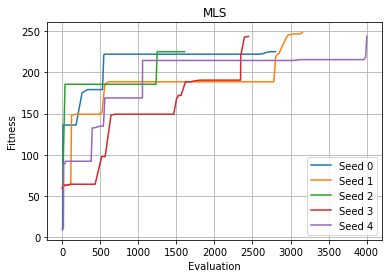

In [167]:
mls_best_list_objectif_economique = [ [c.objectives[0] for c in mls_best_list[i]] for i in range(ONE_NB_SEED) ]

for i in range(ONE_NB_SEED):
    y = np.array(mls_best_list_objectif_economique[i])
    y = np.maximum.accumulate(y)
    plt.plot(mls_index_best_list[i], y, label=f"Seed {i}")
    plt.grid()
    plt.xlabel("Evaluation")
    plt.ylabel("Fitness")
    plt.title(f"MLS")
    plt.legend()
plt.show()

# #4 MILP

In [113]:
model = Model(instance)
time_start = time.time()
s_milp = model.solve(objective="lexicographic", weight=weights, priority=[2, 1, 0], constraints_config=constraints_config, verbose=False)
temps_milp = time.time() - time_start
print("Temps de résolution MILP : ", temps_milp, " secondes")


 ========== SOLVING MODEL ========== 
Set parameter Username
Academic license - for non-commercial use only - expires 2027-01-05
EPS= 0.0001
job with no skills desactived
nb_job_with_no_skills =  0
limite MAKESPAN =  30
constrained makespan activated with limit = 30
constrained makespan activated with self.BORNE_SUP_MAKESPAN = 30
init affectation variables desactivated
Set parameter SolFiles to value "../results/intermediate_solutions.sol"
Optimal solution found with objective value: 257.72679654796656
nObjectives 3
nSolutions 10
et la -> 30
Borne sup makespan: 30
Temps de résolution MILP :  591.8935089111328  secondes


In [114]:
print(s_milp.get_resale_price_job_done())
print(s_milp._resale_price_job_done_plus_task_done())
print(s_milp.compute_objective_values())

240.72679654796656
257.72679654796656
skills 0.9999999999998721
{'0': 257.72679654796656, '1': 0.9999999999998721, '2': -36.14326389892538}


In [115]:

row, ok = validate_model_solution(
    instance=instance,
    solution=s_milp,
    constraints_config=constraints_config,
)
display(pd.DataFrame([row]))

Exécution du test solution_valide...
nb_job_no_skills=0
Exécution du test base_worker...
Exécution du test need_level_if_solo...


,Nom,C_max,Profit,Profit_job_done,Skill_gain,Cognitive_load,solution_valide,base_worker,need_level_if_solo,OK
0,solution,30.0,257.726797,240.726797,1.0,36.143264,PASS,PASS,PASS,TRUE


In [116]:
df = scheduling_to_df(s_milp, instance)

In [117]:
check_df(df)

 ========== CHECKING CONDITIONS FOR GANTT CHART ========== 
df_grouped=
   Operation                   mode  count
0      (1,1)                  alone      1
1      (1,2)                  alone      1
2      (2,1)                  alone      1
3      (2,2)                  alone      1
4      (2,3)                  alone      1
5      (2,4)  learning (apprentice)      1
6      (2,4)       learning (tutor)      1
7      (4,1)        collaboratively      2
8      (4,2)        collaboratively      2
9      (4,3)  learning (apprentice)      1
10     (4,3)       learning (tutor)      1
11     (4,4)                  alone      1
12     (4,5)        collaboratively      2
13     (5,1)        collaboratively      2
14     (5,2)                  alone      1
15     (5,3)                  alone      1
16     (5,4)                  alone      1
17     (7,1)                  alone      1
18     (8,1)                  alone      1
All conditions are satisfied for the Gantt chart.


True

In [159]:
gantt_chart_rich(df)

In [ ]:
gantt_chart_by_job(df, instance)

In [178]:
s_milp_summary = solution_business_report(s_milp, instance)
plot_business_report(s_milp_summary, instance)


═══════════════════════════════════════════════════════
  RAPPORT BUSINESS — SOLUTION MILP
═══════════════════════════════════════════════════════

──────────────────── FINANCIER ────────────────────
  Jobs terminés   : 2/10  (20%)
  CA réalisé      : 240.7 EUR  /  potentiel 734.1 EUR  (33%)
  Makespan        : 30.00

────────────────── AVANCEMENT DES JOBS ─────────────
  Terminés  (2/10) : J4 J5
  En cours  (4/10) :
  J1  [█████████████░░░░░░░] 2/3 ops  (60% diff.)  restant ≈6.2u
       Faites    : Op1✓  Op2✓
       Restantes : Op3⬜
  J2  [█████████████░░░░░░░] 4/6 ops  (63% diff.)  restant ≈18.5u
       Faites    : Op1✓  Op2✓  Op3✓  Op4✓
       Restantes : Op5⬜  Op6⬜
  J7  [█████░░░░░░░░░░░░░░░] 1/4 ops  (23% diff.)  restant ≈19.2u
       Faites    : Op1✓
       Restantes : Op2⬜  Op3⬜  Op4⬜
  J8  [███░░░░░░░░░░░░░░░░░] 1/6 ops  (14% diff.)  restant ≈20.0u
       Faites    : Op1✓
       Restantes : Op2⬜  Op3⬜  Op4⬜  Op5⬜  Op6⬜
  Backlog total estimé : 64.0 unités de temps
  Non comme

In [ ]:
ONE_NB_SEED = 5
MAX_EVAL = 5000

enc2   = Encoding_Dicos(instance)
gen2   = ChromosomeGenerator(instance, enc2, constraints_config=constraints_config2)
dec2   = Decoder(instance, enc2, constraints_config=constraints_config2)
eval2  = Evaluator(dec2, weights)
sel2   = BestSelector()
